<a href="https://colab.research.google.com/github/davidsjohnson/wise24_xai_ac/blob/main/notebooks/tutorial_image_xai_task3_cfs_solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explaining Facial Expression Recognition
# Notebook 1:  XAI for Affective Computing (SoSe2024)

In this notebook you will attempt to generate counterfactual explanations for predictions of an XGBoost facial expression recognition (FER) model trained with tabular (structured) data extracted from images using a subset of the [AffectNet dataset](http://mohammadmahoor.com/affectnet/). AffectNet is an image dataset of facial expressions in the wild, and is labeled with 8 facial expression categories: **Neutral, Happy, Sad, Surprise, Fear, Disgust, Anger, and Contempt**. (Have a look at the paper for more details https://arxiv.org/abs/1708.03985).

Counterfactuals will be genereted using [Diverse Counterfactual Explanations (DICE)](https://interpret.ml/DiCE). From the paper: *Explaining Machine Learning Classifiers through Diverse Counterfactual Explanations*, Mothilal, Sharma, & Tan 2019.


To use this notebook, please make sure to go step by step through each of the cells review the code and comments along the way.


***NOTE**: If using Google Colab, you can use a CPU only runtime as a GPU will not accelerate the XGBoost model.*

## Notebook Setup

Make sure to uncomment code based on if you are running locally or via Google Colab

In [ ]:
## uncomment and run this cell to use Google Colab
!git clone https://github.com/davidsjohnson/wise24_xai_ac.git
# fix xgboost incompatiblity issue
%pip uninstall -y -q scikit-learn
%pip install -q scikit-learn==1.5.2
%pip install dice-ml
%pip install pandas -U

Cloning into 'wise24_xai_ac'...
remote: Enumerating objects: 510, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 510 (delta 23), reused 16 (delta 5), pack-reused 460 (from 1)
Receiving objects: 100% (510/510), 104.96 MiB | 9.28 MiB/s, done.
Resolving deltas: 100% (83/83), done.
Updating files: 100% (400/400), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 46.4 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you ha

In [ ]:
import sys
import os
# sys.path.append(os.path.realpath('../'))  # uncomment this line if you are running this notebook locally
sys.path.append(os.path.realpath('wise24_xai_ac')) # uncomment this line if you are running this notebook on Google Colab

In [ ]:
from pathlib import Path

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import seaborn as sns
import matplotlib.pyplot as plt

from skimage import io

import utils
import img_utils

In [ ]:
pd.__version__

'2.2.3'

In [ ]:
colab = True # change to False if running locally
base_dir = Path('../data/') if not colab else Path('wise24_xai_ac/data/')

## Data Loading

### Loading Images and Action Units

In the next cell, you will load csv files that contain extracted actions units and paths to the corresponding images.  

In [ ]:
# Mapping of Action Units (AUs) to their names
AU_MAP = {
    "AU01": "Inner Brow Raiser",
    "AU02": "Outer Brow Raiser",
    "AU04": "Brow Lowerer",
    "AU05": "Upper Lid Raiser",
    "AU06": "Cheek Raiser",
    "AU07": "Lid Tightener",
    "AU09": "Nose Wrinkler",
    "AU10": "Upper Lip Raiser",
    "AU12": "Lip Corner Puller",
    "AU14": "Dimpler",
    "AU15": "Lip Corner Depressor",
    "AU17": "Chin Raiser",
    "AU20": "Lip Stretcher",
    "AU23": "Lip Tightener",
    "AU25": "Lips Part",
    "AU26": "Jaw Drop",
    "AU28": "Lip Suck",
    "AU45": "Blink",
}

# Generate mappings for both 'r' (regression) and 'c' (classification) versions
AU_FEATURE_MAP = {f"{au}_r": f"{au}-R: {name}" for au, name in AU_MAP.items()}
AU_FEATURE_MAP.update({f"{au}_c": f"{au}-C: {name}" for au, name in AU_MAP.items()})

# Print the mapping
print(AU_FEATURE_MAP)

{'AU01_r': 'AU01-R: Inner Brow Raiser', 'AU02_r': 'AU02-R: Outer Brow Raiser', 'AU04_r': 'AU04-R: Brow Lowerer', 'AU05_r': 'AU05-R: Upper Lid Raiser', 'AU06_r': 'AU06-R: Cheek Raiser', 'AU07_r': 'AU07-R: Lid Tightener', 'AU09_r': 'AU09-R: Nose Wrinkler', 'AU10_r': 'AU10-R: Upper Lip Raiser', 'AU12_r': 'AU12-R: Lip Corner Puller', 'AU14_r': 'AU14-R: Dimpler', 'AU15_r': 'AU15-R: Lip Corner Depressor', 'AU17_r': 'AU17-R: Chin Raiser', 'AU20_r': 'AU20-R: Lip Stretcher', 'AU23_r': 'AU23-R: Lip Tightener', 'AU25_r': 'AU25-R: Lips Part', 'AU26_r': 'AU26-R: Jaw Drop', 'AU28_r': 'AU28-R: Lip Suck', 'AU45_r': 'AU45-R: Blink', 'AU01_c': 'AU01-C: Inner Brow Raiser', 'AU02_c': 'AU02-C: Outer Brow Raiser', 'AU04_c': 'AU04-C: Brow Lowerer', 'AU05_c': 'AU05-C: Upper Lid Raiser', 'AU06_c': 'AU06-C: Cheek Raiser', 'AU07_c': 'AU07-C: Lid Tightener', 'AU09_c': 'AU09-C: Nose Wrinkler', 'AU10_c': 'AU10-C: Upper Lip Raiser', 'AU12_c': 'AU12-C: Lip Corner Puller', 'AU14_c': 'AU14-C: Dimpler', 'AU15_c': 'AU15-

In [ ]:

# Full data from training and evaluation
train_csv = base_dir / 'affectnet_aus/train_aus.csv'
val_csv = base_dir / 'affectnet_aus/val_aus.csv'

# load training and validation data as pandas dataframes
# action units extracted from the AffectNet dataset via OpenFace
df_train = pd.read_csv(train_csv)
df_val = pd.read_csv(val_csv)

# smaller dataset for explanations
xai_csv = base_dir / 'affectnet_aus/eval_aus.csv'
df_xai = pd.read_csv(xai_csv)
df_xai['image'] = df_xai['image'].str.replace('../data', str(base_dir))

# rename columns to make them easier to understand
df_train = df_train.rename(columns=AU_FEATURE_MAP)
df_val = df_val.rename(columns=AU_FEATURE_MAP)
df_xai = df_xai.rename(columns=AU_FEATURE_MAP)

# get only the columns storing action units from the dataframe
# there are also facial landmarks and other features in the dataset could be useful
# but we igore them for now and focus on action units
feature_names = [col for col in df_val.columns if col.startswith('AU')]

# get numerical and categorical features
numerical_features = [feat for feat in feature_names if '-R' in feat]
categorical_features = [feat for feat in feature_names if '-C' in feat]
categorical_idxs = [i for i, feat in enumerate(feature_names) if '-C' in feat]

# setup categorical features for XGBoost
# for feat in categorical_features:
#     df_train[feat] = df_train[feat].astype('category')
#     df_val[feat] = df_val[feat].astype('category')

# get the class labels
class_names = ['Neutral', 'Happy', 'Sad', 'Surprise', 'Fear', 'Disgust', 'Anger', 'Contempt']  # same class labels as before

# Gets all images from folder used for XAI tasks
images = [io.imread(f) for f in df_xai.image]

In [ ]:
# convert categorical features to strings as required by DICE
df_train[categorical_features] = df_train[categorical_features].astype('str')
df_xai[categorical_features] = df_xai[categorical_features].astype('str')
df_train[categorical_features] = df_train[categorical_features].astype('category')
df_xai[categorical_features] = df_xai[categorical_features].astype('category')

## XAI for Tabular Data

In this part, we will generate explanations for the XGBoost model trained using a dataset of Facial Action Units (as described in the notebook introduction).  

First, let's load the data and the trained models. Then we will evaluate the model peformance, before we start with the explanations.

### Setup the Datasets

In [ ]:
X_train = df_train[feature_names]
y_train = df_train['class']
X_test = df_val[feature_names]
y_test = df_val['class']

X_xai = df_xai[feature_names]
y_xai = df_xai['class']

print('Training data shape:', X_train.shape, y_train.shape)
print('Test data shape:', X_test.shape, y_test.shape)
print('XAI data shape:', X_xai.shape, y_xai.shape)

Training data shape: (36685, 35) (36685,)
Test data shape: (3908, 35) (3908,)
XAI data shape: (80, 35) (80,)


### Train the Model

Now let's train the Random Forest Classifier on the split dataset. The accuracy of the model in the training data should be around $99\%$

In [ ]:
# # Train model from scratch
random_state = 10
clf = RandomForestClassifier(random_state=random_state)

# clf = XGBClassifier(booster='gbtree', enable_categorical=False, max_depth=15, eta=0.1, reg_lambda=30, random_state=random_state)
clf.fit(X_train, y_train)
clf.score(X_train, y_train)

0.9965108354913452

### Evaluate the Model

Now we will evaluate it on the test dataset. Unfortunately, the accuracy is only $43\%$ but this is still well above chance guessing which would be $1 / 8 * 100 = 12.5\%$ accuracy (since there are 8 total classes)

In [ ]:
# get model predictions
y_test_preds = clf.predict(X_test)
y_test_true = y_test

# eval results
print(classification_report(y_test_true, y_test_preds, target_names=class_names))

              precision    recall  f1-score   support

     Neutral       0.31      0.41      0.36       485
       Happy       0.56      0.70      0.63       488
         Sad       0.36      0.38      0.37       490
    Surprise       0.42      0.42      0.42       488
        Fear       0.50      0.47      0.49       487
     Disgust       0.52      0.35      0.42       493
       Anger       0.37      0.42      0.39       482
    Contempt       0.43      0.28      0.34       495

    accuracy                           0.43      3908
   macro avg       0.43      0.43      0.43      3908
weighted avg       0.43      0.43      0.43      3908



We can also review the confusion matrix to see where the model makes its mistakes

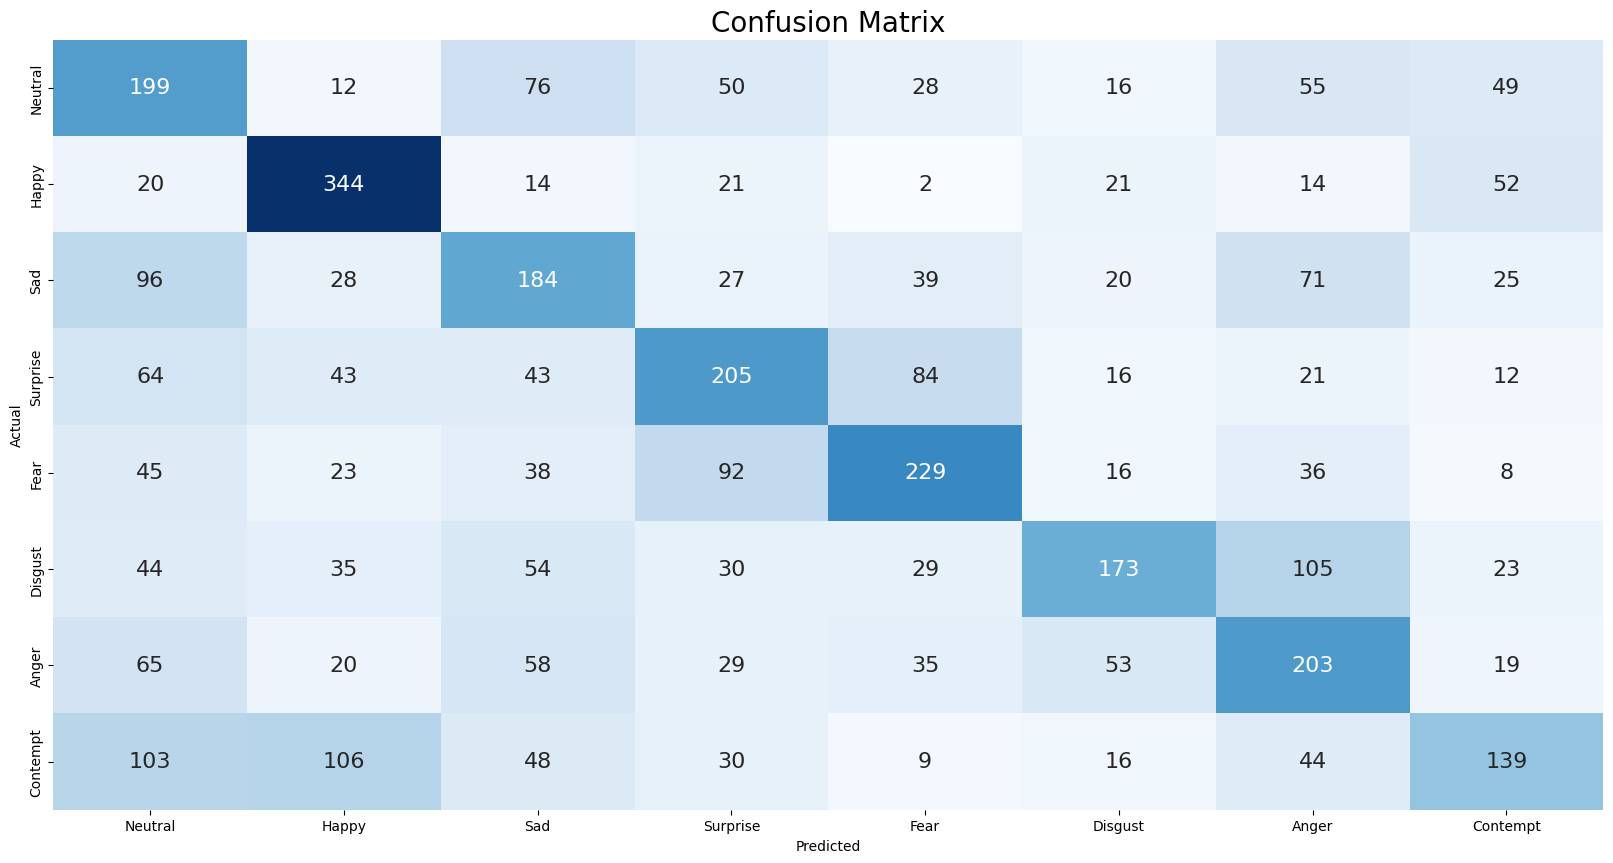

In [ ]:
cm_data = confusion_matrix(y_test_true, y_test_preds)
cm = pd.DataFrame(cm_data, columns=class_names, index=class_names)
cm.index.name = 'Actual'
cm.columns.name = 'Predicted'
plt.figure(figsize = (20,10))
plt.title('Confusion Matrix', fontsize = 20)
sns.set(font_scale=1.2)
ax = sns.heatmap(cm, cbar=False, cmap="Blues", annot=True, annot_kws={"size": 16}, fmt='g')

### Setup XAI dataset and Predictions

In [ ]:
# Evaluate model on XAI data
y_xai_preds = clf.predict(X_xai)
y_xai_true = y_xai

df_xai['pred'] = y_xai_preds

print(classification_report(y_xai_true, y_xai_preds, target_names=class_names))

              precision    recall  f1-score   support

     Neutral       0.25      0.40      0.31        10
       Happy       0.64      0.70      0.67        10
         Sad       0.56      0.50      0.53        10
    Surprise       0.44      0.40      0.42        10
        Fear       0.45      0.50      0.48        10
     Disgust       0.60      0.30      0.40        10
       Anger       0.27      0.40      0.32        10
    Contempt       0.75      0.30      0.43        10

    accuracy                           0.44        80
   macro avg       0.49      0.44      0.44        80
weighted avg       0.49      0.44      0.44        80



## Generate Explanations

In this notebook you will generate both global and local explanations for the XGBoost model using a counterfactual method called DiCE. Review the [DiCE Documentation for Details](https://interpret.ml/DiCE/)

In [ ]:
# # uncomment if using Google Colab
# %pip install dice-ml
# %pip install pandas -U

In [ ]:
import dice_ml

pd.set_option('display.max_columns', None) # so that Jupyter doesn't truncate columns of dataframe

### Task 1 - Generate Counterfactuals

**Task 1.1:** Select 6 image that you want to gain explanations for. Choose 3 correct and 3 incorrect explanations
- You will also need to choose corresponding "desired" classes for each selection.

**Task 1.2:** Generate and display 5 counterfactual examples for each selection using [DiCE](https://interpret.ml/DiCE/index.html).  The counterfactuals should be displayed as a dataframe and should include the original image, model prediction and ground truth along side it.

Here is a good example to help get you started: [Intro to Counterfactuals with Dice](https://interpret.ml/DiCE/notebooks/DiCE_getting_started.html)

**Task 1.3** Answer Question 1 below

**Preview the Dataset with Predictions**

The code below will display images from the XAI dataset.
- Try changing value of `start` to get a new set of images (there are 10 images for each class; for example, the class happy will be at indexes 10-19)
- Search through the images to find some that might be interesting to Explain
- Since counterfactuals are always in reference to some other class in multi class problems, you should also define the "desired" class for each selected example

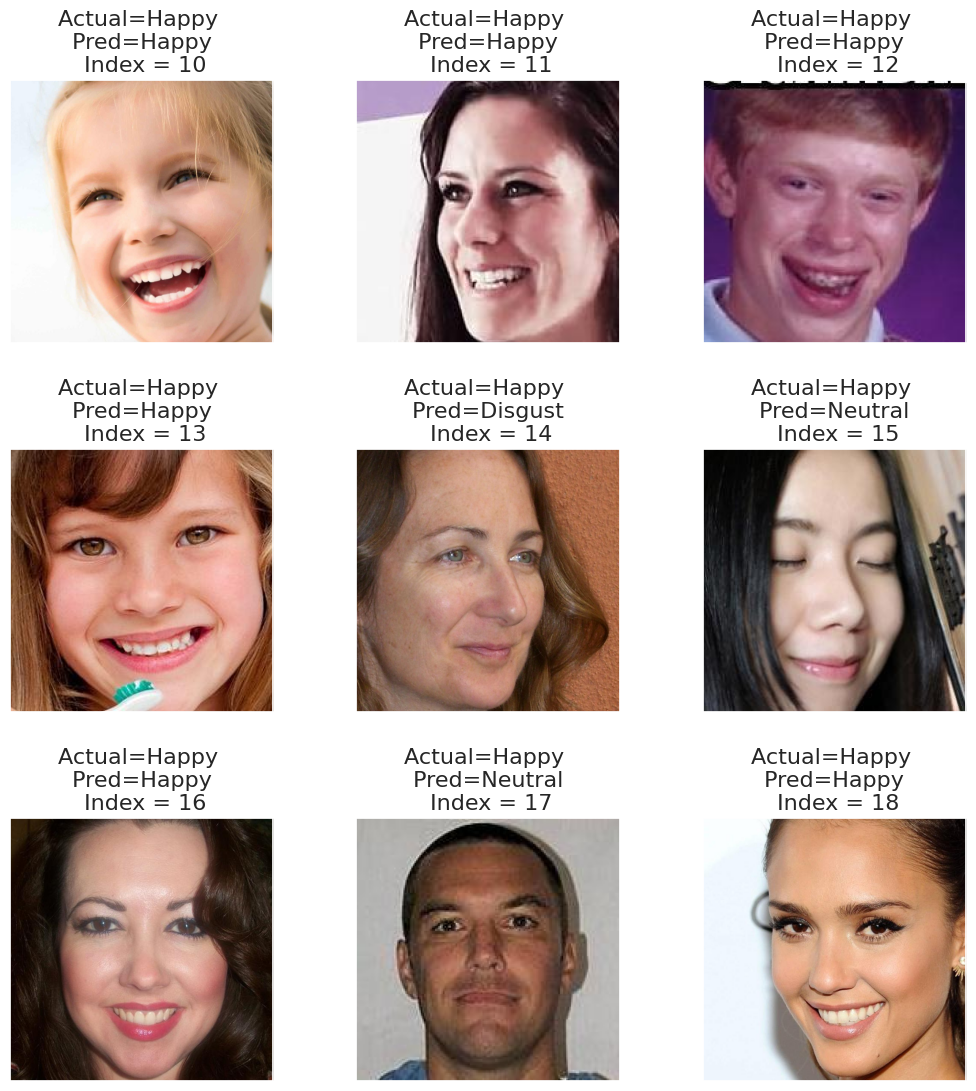

In [ ]:
start=10
img_utils.display_nine_images(images, df_xai['class'], df_xai['pred'], start)

In [ ]:
###### Enter your Code Here ######
##################################

img_idxs_corr = []
desired_classes_corr = []

img_idxs_incorr = []
desired_classes_incorr = []

In [ ]:
###### Enter your Code Here ######
##################################

img_idxs_corr = [16, 39, 60]
desired_classes_corr = [0, 0, 0]

img_idxs_incorr = [14, 56, 65]
desired_classes_incorr = [class_names.index('Happy'), class_names.index('Disgust'), class_names.index('Disgust')]

In [ ]:
d = dice_ml.Data(dataframe=df_train[feature_names + ['class']], continuous_features=numerical_features, outcome_name='class')
m = dice_ml.Model(model=clf, backend='sklearn')
exp = dice_ml.Dice(d, m)

In [ ]:
exps_corr = []
for idx, desired in zip(img_idxs_corr, desired_classes_corr):
    e = exp.generate_counterfactuals(df_xai[feature_names][idx:idx+1], total_CFs=5, desired_class=desired)
    exps_corr.append(e)

exps_incorr = []
for idx, desired in zip(img_idxs_incorr, desired_classes_incorr):
    e = exp.generate_counterfactuals(df_xai[feature_names][idx:idx+1], total_CFs=5, desired_class=desired)
    exps_incorr.append(e)

100%|██████████| 1/1 [00:00<00:00,  1.27it/s]


In [ ]:
pd.set_option('display.max_columns', None) # so that Jupyter doesn't truncate columns of dataframe

def show_exp(exp, img_idx, desired_class):

  true = df_xai.iloc[img_idx]['class']
  true_label = class_names[true]
  pred = df_xai.iloc[img_idx]['pred']
  pred_label = class_names[pred]
  desired = class_names[desired_class]

  print(f'###################################')
  print(f'###################################')
  print(f'#### Instance {img_idx} - True: {true_label} ({true}), Pred: {pred_label} ({pred})')
  print(f'#### Desired Outcome: {desired} ({desired_class})')
  print()
  img_utils.display_one_image(images[img_idx], '', (1, 1, 1))
  plt.show()
  e.visualize_as_dataframe(show_only_changes=True)
  print()
  print()
  print()

###################################
###################################
#### Instance 16 - True: Happy (1), Pred: Happy (1)
#### Desired Outcome: Neutral (0)



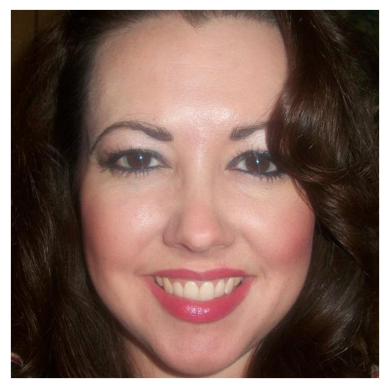

Query instance (original outcome : 2)


,AU01-R: Inner Brow Raiser,AU02-R: Outer Brow Raiser,AU04-R: Brow Lowerer,AU05-R: Upper Lid Raiser,AU06-R: Cheek Raiser,AU07-R: Lid Tightener,AU09-R: Nose Wrinkler,AU10-R: Upper Lip Raiser,AU12-R: Lip Corner Puller,AU14-R: Dimpler,AU15-R: Lip Corner Depressor,AU17-R: Chin Raiser,AU20-R: Lip Stretcher,AU23-R: Lip Tightener,AU25-R: Lips Part,AU26-R: Jaw Drop,AU45-R: Blink,AU01-C: Inner Brow Raiser,AU02-C: Outer Brow Raiser,AU04-C: Brow Lowerer,AU05-C: Upper Lid Raiser,AU06-C: Cheek Raiser,AU07-C: Lid Tightener,AU09-C: Nose Wrinkler,AU10-C: Upper Lip Raiser,AU12-C: Lip Corner Puller,AU14-C: Dimpler,AU15-C: Lip Corner Depressor,AU17-C: Chin Raiser,AU20-C: Lip Stretcher,AU23-C: Lip Tightener,AU25-C: Lips Part,AU26-C: Jaw Drop,AU28-C: Lip Suck,AU45-C: Blink,class
0,1.08,0.59,0.0,1.53,0.0,0.0,0.44,0.8,0.0,0.0,2.29,0.55,1.88,0.24,0.0,0.59,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2



Diverse Counterfactual set (new outcome: 5)


,AU01-R: Inner Brow Raiser,AU02-R: Outer Brow Raiser,AU04-R: Brow Lowerer,AU05-R: Upper Lid Raiser,AU06-R: Cheek Raiser,AU07-R: Lid Tightener,AU09-R: Nose Wrinkler,AU10-R: Upper Lip Raiser,AU12-R: Lip Corner Puller,AU14-R: Dimpler,AU15-R: Lip Corner Depressor,AU17-R: Chin Raiser,AU20-R: Lip Stretcher,AU23-R: Lip Tightener,AU25-R: Lips Part,AU26-R: Jaw Drop,AU45-R: Blink,AU01-C: Inner Brow Raiser,AU02-C: Outer Brow Raiser,AU04-C: Brow Lowerer,AU05-C: Upper Lid Raiser,AU06-C: Cheek Raiser,AU07-C: Lid Tightener,AU09-C: Nose Wrinkler,AU10-C: Upper Lip Raiser,AU12-C: Lip Corner Puller,AU14-C: Dimpler,AU15-C: Lip Corner Depressor,AU17-C: Chin Raiser,AU20-C: Lip Stretcher,AU23-C: Lip Tightener,AU25-C: Lips Part,AU26-C: Jaw Drop,AU28-C: Lip Suck,AU45-C: Blink,class
0,0.6,-,-,-,-,4.8,2.4,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,5
1,-,-,0.9,-,-,4.0,3.9,-,-,-,-,-,1.9000000000000001,-,-,-,-,-,-,-,-,-,-,1.0,-,-,-,-,-,-,-,-,-,-,-,5
2,0.6,-,-,-,1.3,4.8,2.4,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,5
3,-,-,-,-,-,-,2.4,-,-,-,-,-,1.9,2.7,-,-,-,-,-,-,-,-,-,-,-,1.0,-,-,-,-,-,-,-,-,-,5
4,-,-,-,-,-,4.5,4.2,3.4,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,5


In [ ]:
show_exp(exps_corr[0], img_idxs_corr[0], desired_classes_corr[0])

###################################
###################################
#### Instance 39 - True: Surprise (3), Pred: Surprise (3)
#### Desired Outcome: Neutral (0)



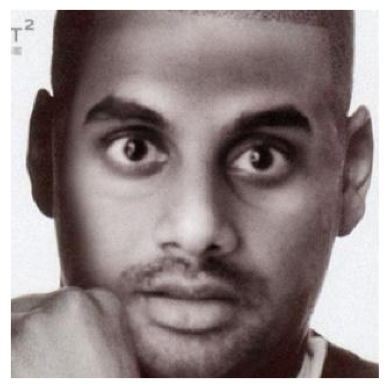

Query instance (original outcome : 2)


,AU01-R: Inner Brow Raiser,AU02-R: Outer Brow Raiser,AU04-R: Brow Lowerer,AU05-R: Upper Lid Raiser,AU06-R: Cheek Raiser,AU07-R: Lid Tightener,AU09-R: Nose Wrinkler,AU10-R: Upper Lip Raiser,AU12-R: Lip Corner Puller,AU14-R: Dimpler,AU15-R: Lip Corner Depressor,AU17-R: Chin Raiser,AU20-R: Lip Stretcher,AU23-R: Lip Tightener,AU25-R: Lips Part,AU26-R: Jaw Drop,AU45-R: Blink,AU01-C: Inner Brow Raiser,AU02-C: Outer Brow Raiser,AU04-C: Brow Lowerer,AU05-C: Upper Lid Raiser,AU06-C: Cheek Raiser,AU07-C: Lid Tightener,AU09-C: Nose Wrinkler,AU10-C: Upper Lip Raiser,AU12-C: Lip Corner Puller,AU14-C: Dimpler,AU15-C: Lip Corner Depressor,AU17-C: Chin Raiser,AU20-C: Lip Stretcher,AU23-C: Lip Tightener,AU25-C: Lips Part,AU26-C: Jaw Drop,AU28-C: Lip Suck,AU45-C: Blink,class
0,1.08,0.59,0.0,1.53,0.0,0.0,0.44,0.8,0.0,0.0,2.29,0.55,1.88,0.24,0.0,0.59,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2



Diverse Counterfactual set (new outcome: 5)


,AU01-R: Inner Brow Raiser,AU02-R: Outer Brow Raiser,AU04-R: Brow Lowerer,AU05-R: Upper Lid Raiser,AU06-R: Cheek Raiser,AU07-R: Lid Tightener,AU09-R: Nose Wrinkler,AU10-R: Upper Lip Raiser,AU12-R: Lip Corner Puller,AU14-R: Dimpler,AU15-R: Lip Corner Depressor,AU17-R: Chin Raiser,AU20-R: Lip Stretcher,AU23-R: Lip Tightener,AU25-R: Lips Part,AU26-R: Jaw Drop,AU45-R: Blink,AU01-C: Inner Brow Raiser,AU02-C: Outer Brow Raiser,AU04-C: Brow Lowerer,AU05-C: Upper Lid Raiser,AU06-C: Cheek Raiser,AU07-C: Lid Tightener,AU09-C: Nose Wrinkler,AU10-C: Upper Lip Raiser,AU12-C: Lip Corner Puller,AU14-C: Dimpler,AU15-C: Lip Corner Depressor,AU17-C: Chin Raiser,AU20-C: Lip Stretcher,AU23-C: Lip Tightener,AU25-C: Lips Part,AU26-C: Jaw Drop,AU28-C: Lip Suck,AU45-C: Blink,class
0,0.6,-,-,-,-,4.8,2.4,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,5
1,-,-,0.9,-,-,4.0,3.9,-,-,-,-,-,1.9000000000000001,-,-,-,-,-,-,-,-,-,-,1.0,-,-,-,-,-,-,-,-,-,-,-,5
2,0.6,-,-,-,1.3,4.8,2.4,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,5
3,-,-,-,-,-,-,2.4,-,-,-,-,-,1.9,2.7,-,-,-,-,-,-,-,-,-,-,-,1.0,-,-,-,-,-,-,-,-,-,5
4,-,-,-,-,-,4.5,4.2,3.4,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,5


In [ ]:
show_exp(exps_corr[1], img_idxs_corr[1], desired_classes_corr[1])

###################################
###################################
#### Instance 60 - True: Anger (6), Pred: Anger (6)
#### Desired Outcome: Neutral (0)



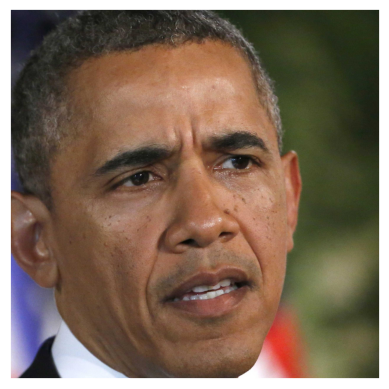

Query instance (original outcome : 2)


,AU01-R: Inner Brow Raiser,AU02-R: Outer Brow Raiser,AU04-R: Brow Lowerer,AU05-R: Upper Lid Raiser,AU06-R: Cheek Raiser,AU07-R: Lid Tightener,AU09-R: Nose Wrinkler,AU10-R: Upper Lip Raiser,AU12-R: Lip Corner Puller,AU14-R: Dimpler,AU15-R: Lip Corner Depressor,AU17-R: Chin Raiser,AU20-R: Lip Stretcher,AU23-R: Lip Tightener,AU25-R: Lips Part,AU26-R: Jaw Drop,AU45-R: Blink,AU01-C: Inner Brow Raiser,AU02-C: Outer Brow Raiser,AU04-C: Brow Lowerer,AU05-C: Upper Lid Raiser,AU06-C: Cheek Raiser,AU07-C: Lid Tightener,AU09-C: Nose Wrinkler,AU10-C: Upper Lip Raiser,AU12-C: Lip Corner Puller,AU14-C: Dimpler,AU15-C: Lip Corner Depressor,AU17-C: Chin Raiser,AU20-C: Lip Stretcher,AU23-C: Lip Tightener,AU25-C: Lips Part,AU26-C: Jaw Drop,AU28-C: Lip Suck,AU45-C: Blink,class
0,1.08,0.59,0.0,1.53,0.0,0.0,0.44,0.8,0.0,0.0,2.29,0.55,1.88,0.24,0.0,0.59,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2



Diverse Counterfactual set (new outcome: 5)


,AU01-R: Inner Brow Raiser,AU02-R: Outer Brow Raiser,AU04-R: Brow Lowerer,AU05-R: Upper Lid Raiser,AU06-R: Cheek Raiser,AU07-R: Lid Tightener,AU09-R: Nose Wrinkler,AU10-R: Upper Lip Raiser,AU12-R: Lip Corner Puller,AU14-R: Dimpler,AU15-R: Lip Corner Depressor,AU17-R: Chin Raiser,AU20-R: Lip Stretcher,AU23-R: Lip Tightener,AU25-R: Lips Part,AU26-R: Jaw Drop,AU45-R: Blink,AU01-C: Inner Brow Raiser,AU02-C: Outer Brow Raiser,AU04-C: Brow Lowerer,AU05-C: Upper Lid Raiser,AU06-C: Cheek Raiser,AU07-C: Lid Tightener,AU09-C: Nose Wrinkler,AU10-C: Upper Lip Raiser,AU12-C: Lip Corner Puller,AU14-C: Dimpler,AU15-C: Lip Corner Depressor,AU17-C: Chin Raiser,AU20-C: Lip Stretcher,AU23-C: Lip Tightener,AU25-C: Lips Part,AU26-C: Jaw Drop,AU28-C: Lip Suck,AU45-C: Blink,class
0,0.6,-,-,-,-,4.8,2.4,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,5
1,-,-,0.9,-,-,4.0,3.9,-,-,-,-,-,1.9000000000000001,-,-,-,-,-,-,-,-,-,-,1.0,-,-,-,-,-,-,-,-,-,-,-,5
2,0.6,-,-,-,1.3,4.8,2.4,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,5
3,-,-,-,-,-,-,2.4,-,-,-,-,-,1.9,2.7,-,-,-,-,-,-,-,-,-,-,-,1.0,-,-,-,-,-,-,-,-,-,5
4,-,-,-,-,-,4.5,4.2,3.4,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,5


In [ ]:
show_exp(exps_corr[2], img_idxs_corr[2], desired_classes_corr[2])

###################################
###################################
#### Instance 14 - True: Happy (1), Pred: Disgust (5)
#### Desired Outcome: Happy (1)



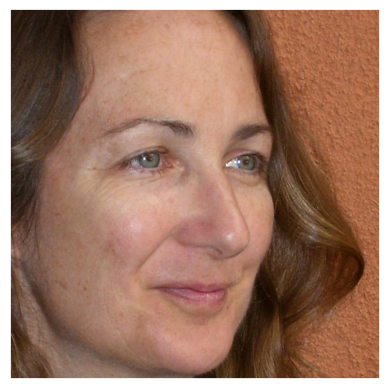

Query instance (original outcome : 2)


,AU01-R: Inner Brow Raiser,AU02-R: Outer Brow Raiser,AU04-R: Brow Lowerer,AU05-R: Upper Lid Raiser,AU06-R: Cheek Raiser,AU07-R: Lid Tightener,AU09-R: Nose Wrinkler,AU10-R: Upper Lip Raiser,AU12-R: Lip Corner Puller,AU14-R: Dimpler,AU15-R: Lip Corner Depressor,AU17-R: Chin Raiser,AU20-R: Lip Stretcher,AU23-R: Lip Tightener,AU25-R: Lips Part,AU26-R: Jaw Drop,AU45-R: Blink,AU01-C: Inner Brow Raiser,AU02-C: Outer Brow Raiser,AU04-C: Brow Lowerer,AU05-C: Upper Lid Raiser,AU06-C: Cheek Raiser,AU07-C: Lid Tightener,AU09-C: Nose Wrinkler,AU10-C: Upper Lip Raiser,AU12-C: Lip Corner Puller,AU14-C: Dimpler,AU15-C: Lip Corner Depressor,AU17-C: Chin Raiser,AU20-C: Lip Stretcher,AU23-C: Lip Tightener,AU25-C: Lips Part,AU26-C: Jaw Drop,AU28-C: Lip Suck,AU45-C: Blink,class
0,1.08,0.59,0.0,1.53,0.0,0.0,0.44,0.8,0.0,0.0,2.29,0.55,1.88,0.24,0.0,0.59,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2



Diverse Counterfactual set (new outcome: 5)


,AU01-R: Inner Brow Raiser,AU02-R: Outer Brow Raiser,AU04-R: Brow Lowerer,AU05-R: Upper Lid Raiser,AU06-R: Cheek Raiser,AU07-R: Lid Tightener,AU09-R: Nose Wrinkler,AU10-R: Upper Lip Raiser,AU12-R: Lip Corner Puller,AU14-R: Dimpler,AU15-R: Lip Corner Depressor,AU17-R: Chin Raiser,AU20-R: Lip Stretcher,AU23-R: Lip Tightener,AU25-R: Lips Part,AU26-R: Jaw Drop,AU45-R: Blink,AU01-C: Inner Brow Raiser,AU02-C: Outer Brow Raiser,AU04-C: Brow Lowerer,AU05-C: Upper Lid Raiser,AU06-C: Cheek Raiser,AU07-C: Lid Tightener,AU09-C: Nose Wrinkler,AU10-C: Upper Lip Raiser,AU12-C: Lip Corner Puller,AU14-C: Dimpler,AU15-C: Lip Corner Depressor,AU17-C: Chin Raiser,AU20-C: Lip Stretcher,AU23-C: Lip Tightener,AU25-C: Lips Part,AU26-C: Jaw Drop,AU28-C: Lip Suck,AU45-C: Blink,class
0,0.6,-,-,-,-,4.8,2.4,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,5
1,-,-,0.9,-,-,4.0,3.9,-,-,-,-,-,1.9000000000000001,-,-,-,-,-,-,-,-,-,-,1.0,-,-,-,-,-,-,-,-,-,-,-,5
2,0.6,-,-,-,1.3,4.8,2.4,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,5
3,-,-,-,-,-,-,2.4,-,-,-,-,-,1.9,2.7,-,-,-,-,-,-,-,-,-,-,-,1.0,-,-,-,-,-,-,-,-,-,5
4,-,-,-,-,-,4.5,4.2,3.4,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,5


In [ ]:
show_exp(exps_incorr[0], img_idxs_incorr[0], desired_classes_incorr[0])

###################################
###################################
#### Instance 56 - True: Disgust (5), Pred: Anger (6)
#### Desired Outcome: Disgust (5)



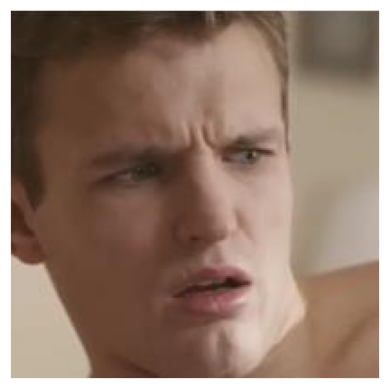

Query instance (original outcome : 2)


,AU01-R: Inner Brow Raiser,AU02-R: Outer Brow Raiser,AU04-R: Brow Lowerer,AU05-R: Upper Lid Raiser,AU06-R: Cheek Raiser,AU07-R: Lid Tightener,AU09-R: Nose Wrinkler,AU10-R: Upper Lip Raiser,AU12-R: Lip Corner Puller,AU14-R: Dimpler,AU15-R: Lip Corner Depressor,AU17-R: Chin Raiser,AU20-R: Lip Stretcher,AU23-R: Lip Tightener,AU25-R: Lips Part,AU26-R: Jaw Drop,AU45-R: Blink,AU01-C: Inner Brow Raiser,AU02-C: Outer Brow Raiser,AU04-C: Brow Lowerer,AU05-C: Upper Lid Raiser,AU06-C: Cheek Raiser,AU07-C: Lid Tightener,AU09-C: Nose Wrinkler,AU10-C: Upper Lip Raiser,AU12-C: Lip Corner Puller,AU14-C: Dimpler,AU15-C: Lip Corner Depressor,AU17-C: Chin Raiser,AU20-C: Lip Stretcher,AU23-C: Lip Tightener,AU25-C: Lips Part,AU26-C: Jaw Drop,AU28-C: Lip Suck,AU45-C: Blink,class
0,1.08,0.59,0.0,1.53,0.0,0.0,0.44,0.8,0.0,0.0,2.29,0.55,1.88,0.24,0.0,0.59,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2



Diverse Counterfactual set (new outcome: 5)


,AU01-R: Inner Brow Raiser,AU02-R: Outer Brow Raiser,AU04-R: Brow Lowerer,AU05-R: Upper Lid Raiser,AU06-R: Cheek Raiser,AU07-R: Lid Tightener,AU09-R: Nose Wrinkler,AU10-R: Upper Lip Raiser,AU12-R: Lip Corner Puller,AU14-R: Dimpler,AU15-R: Lip Corner Depressor,AU17-R: Chin Raiser,AU20-R: Lip Stretcher,AU23-R: Lip Tightener,AU25-R: Lips Part,AU26-R: Jaw Drop,AU45-R: Blink,AU01-C: Inner Brow Raiser,AU02-C: Outer Brow Raiser,AU04-C: Brow Lowerer,AU05-C: Upper Lid Raiser,AU06-C: Cheek Raiser,AU07-C: Lid Tightener,AU09-C: Nose Wrinkler,AU10-C: Upper Lip Raiser,AU12-C: Lip Corner Puller,AU14-C: Dimpler,AU15-C: Lip Corner Depressor,AU17-C: Chin Raiser,AU20-C: Lip Stretcher,AU23-C: Lip Tightener,AU25-C: Lips Part,AU26-C: Jaw Drop,AU28-C: Lip Suck,AU45-C: Blink,class
0,0.6,-,-,-,-,4.8,2.4,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,5
1,-,-,0.9,-,-,4.0,3.9,-,-,-,-,-,1.9000000000000001,-,-,-,-,-,-,-,-,-,-,1.0,-,-,-,-,-,-,-,-,-,-,-,5
2,0.6,-,-,-,1.3,4.8,2.4,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,5
3,-,-,-,-,-,-,2.4,-,-,-,-,-,1.9,2.7,-,-,-,-,-,-,-,-,-,-,-,1.0,-,-,-,-,-,-,-,-,-,5
4,-,-,-,-,-,4.5,4.2,3.4,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,5


In [ ]:
show_exp(exps_incorr[1], img_idxs_incorr[1], desired_classes_incorr[1])

###################################
###################################
#### Instance 65 - True: Anger (6), Pred: Sad (2)
#### Desired Outcome: Disgust (5)



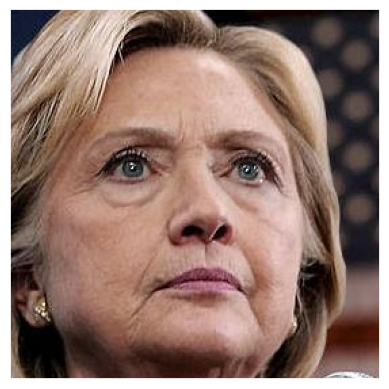

Query instance (original outcome : 2)


,AU01-R: Inner Brow Raiser,AU02-R: Outer Brow Raiser,AU04-R: Brow Lowerer,AU05-R: Upper Lid Raiser,AU06-R: Cheek Raiser,AU07-R: Lid Tightener,AU09-R: Nose Wrinkler,AU10-R: Upper Lip Raiser,AU12-R: Lip Corner Puller,AU14-R: Dimpler,AU15-R: Lip Corner Depressor,AU17-R: Chin Raiser,AU20-R: Lip Stretcher,AU23-R: Lip Tightener,AU25-R: Lips Part,AU26-R: Jaw Drop,AU45-R: Blink,AU01-C: Inner Brow Raiser,AU02-C: Outer Brow Raiser,AU04-C: Brow Lowerer,AU05-C: Upper Lid Raiser,AU06-C: Cheek Raiser,AU07-C: Lid Tightener,AU09-C: Nose Wrinkler,AU10-C: Upper Lip Raiser,AU12-C: Lip Corner Puller,AU14-C: Dimpler,AU15-C: Lip Corner Depressor,AU17-C: Chin Raiser,AU20-C: Lip Stretcher,AU23-C: Lip Tightener,AU25-C: Lips Part,AU26-C: Jaw Drop,AU28-C: Lip Suck,AU45-C: Blink,class
0,1.08,0.59,0.0,1.53,0.0,0.0,0.44,0.8,0.0,0.0,2.29,0.55,1.88,0.24,0.0,0.59,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2



Diverse Counterfactual set (new outcome: 5)


,AU01-R: Inner Brow Raiser,AU02-R: Outer Brow Raiser,AU04-R: Brow Lowerer,AU05-R: Upper Lid Raiser,AU06-R: Cheek Raiser,AU07-R: Lid Tightener,AU09-R: Nose Wrinkler,AU10-R: Upper Lip Raiser,AU12-R: Lip Corner Puller,AU14-R: Dimpler,AU15-R: Lip Corner Depressor,AU17-R: Chin Raiser,AU20-R: Lip Stretcher,AU23-R: Lip Tightener,AU25-R: Lips Part,AU26-R: Jaw Drop,AU45-R: Blink,AU01-C: Inner Brow Raiser,AU02-C: Outer Brow Raiser,AU04-C: Brow Lowerer,AU05-C: Upper Lid Raiser,AU06-C: Cheek Raiser,AU07-C: Lid Tightener,AU09-C: Nose Wrinkler,AU10-C: Upper Lip Raiser,AU12-C: Lip Corner Puller,AU14-C: Dimpler,AU15-C: Lip Corner Depressor,AU17-C: Chin Raiser,AU20-C: Lip Stretcher,AU23-C: Lip Tightener,AU25-C: Lips Part,AU26-C: Jaw Drop,AU28-C: Lip Suck,AU45-C: Blink,class
0,0.6,-,-,-,-,4.8,2.4,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,5
1,-,-,0.9,-,-,4.0,3.9,-,-,-,-,-,1.9000000000000001,-,-,-,-,-,-,-,-,-,-,1.0,-,-,-,-,-,-,-,-,-,-,-,5
2,0.6,-,-,-,1.3,4.8,2.4,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,5
3,-,-,-,-,-,-,2.4,-,-,-,-,-,1.9,2.7,-,-,-,-,-,-,-,-,-,-,-,1.0,-,-,-,-,-,-,-,-,-,5
4,-,-,-,-,-,4.5,4.2,3.4,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,5


In [ ]:
show_exp(exps_incorr[2], img_idxs_incorr[2], desired_classes_incorr[2])

#### Question 1

**Q 1.a**

Provide one or two paragraphs on your findings.

Here some some ideas to reflect on but you're not limited to these.
  

*   How do you interpret these results?
*   What interesting insights did you find?  
*   What are some limitations in this approach?

**Q 1.b**

Why does DiCE require a "desired" class?  What are good values to select for the desired class in a multi class task like facial expression recognition?

### Task 2 - Generate Local Explanations

In this task you will generate feature importance scores based on counterfactuals using DiCE

Here is an example from the document that will help: [Estimating local and global feature importance scores using DiCE](https://interpret.ml/DiCE/notebooks/DiCE_feature_importances.html)

**Task 2.1:** Generate and plot local feature importance scores for each image. With each plot, you should also include the original image, model prediction and ground truth.

**Task 2.2:** Generate and plot global feature importance scores for each class.

**Task 2.3:** Answer Question 2 below.

In [ ]:
from IPython.display import display # (use display to display a dataframe)

# helper function for plotting importance dictionaries provided by DiCE
def plot_importance_dict(importance_dict, ax=None):
    keys = list(importance_dict.keys())
    vals = [float(importance_dict[k]) for k in keys]
    sns.barplot(x=keys, y=vals, ax=ax)
    plt.xticks(rotation=90)

In [ ]:
###### Enter your Code Here ######
##################################



In [ ]:
########## SOLUTION ###########
###############################
def plot_local_importance(img_idx, desired_class):

  true = df_xai.iloc[img_idx]['class']
  true_label = class_names[true]
  pred = df_xai.iloc[img_idx]['pred']
  pred_label = class_names[pred]
  desired = class_names[desired_class]

  print(f'###################################')
  print(f'###################################')
  print(f'#### Instance {img_idx} - True: {true_label} ({true}), Pred: {pred_label} ({pred})')
  print(f'#### Desired Outcome: {desired} ({desired_class})')
  print()

  display(df_xai[feature_names].iloc[img_idx:img_idx+1])
  print()
  imp = exp.local_feature_importance(df_xai[feature_names][img_idx:img_idx+1], total_CFs=20, desired_class=desired_class)

  fig, axes = plt.subplots(1, 2, figsize=(28, 4))

  axes[0].imshow(images[img_idx])
  axes[0].set_title(f'True: {true_label} ({true}), Pred: {pred_label} ({pred})')
  axes[0].axis('off')
  plot_importance_dict(imp.local_importance[0], axes[1])
  plt.show()

In [ ]:
imp = exp.local_feature_importance(df_xai[feature_names][2:3], total_CFs=20, desired_class=0)

100%|██████████| 1/1 [00:00<00:00,  1.04it/s]


In [ ]:
pd.__version__

'2.2.3'

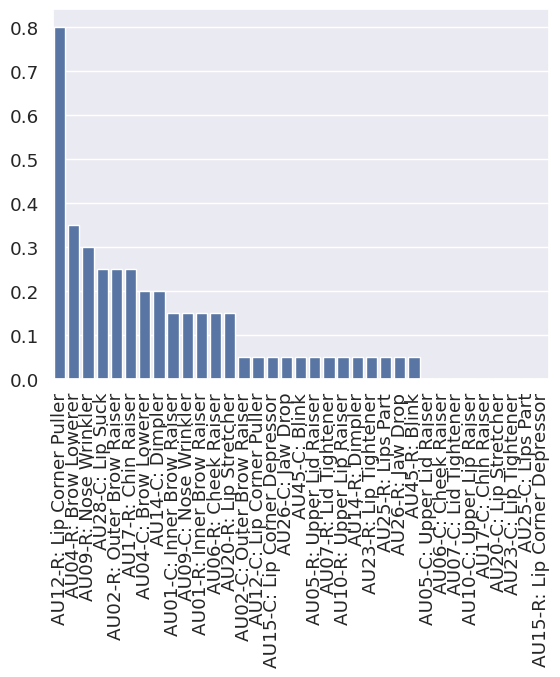

In [ ]:
plot_importance_dict(imp.local_importance[0])

###################################
###################################
#### Instance 16 - True: Happy (1), Pred: Happy (1)
#### Desired Outcome: Neutral (0)



,AU01-R: Inner Brow Raiser,AU02-R: Outer Brow Raiser,AU04-R: Brow Lowerer,AU05-R: Upper Lid Raiser,AU06-R: Cheek Raiser,AU07-R: Lid Tightener,AU09-R: Nose Wrinkler,AU10-R: Upper Lip Raiser,AU12-R: Lip Corner Puller,AU14-R: Dimpler,AU15-R: Lip Corner Depressor,AU17-R: Chin Raiser,AU20-R: Lip Stretcher,AU23-R: Lip Tightener,AU25-R: Lips Part,AU26-R: Jaw Drop,AU45-R: Blink,AU01-C: Inner Brow Raiser,AU02-C: Outer Brow Raiser,AU04-C: Brow Lowerer,AU05-C: Upper Lid Raiser,AU06-C: Cheek Raiser,AU07-C: Lid Tightener,AU09-C: Nose Wrinkler,AU10-C: Upper Lip Raiser,AU12-C: Lip Corner Puller,AU14-C: Dimpler,AU15-C: Lip Corner Depressor,AU17-C: Chin Raiser,AU20-C: Lip Stretcher,AU23-C: Lip Tightener,AU25-C: Lips Part,AU26-C: Jaw Drop,AU28-C: Lip Suck,AU45-C: Blink
16,0.12,0.01,0.75,0.0,1.71,0.04,0.0,2.06,2.96,2.61,0.0,0.0,0.0,0.01,3.17,0.02,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


100%|██████████| 1/1 [00:02<00:00,  2.85s/it]


ModuleNotFoundError: No module named 'pandas.core.methods.to_dict'

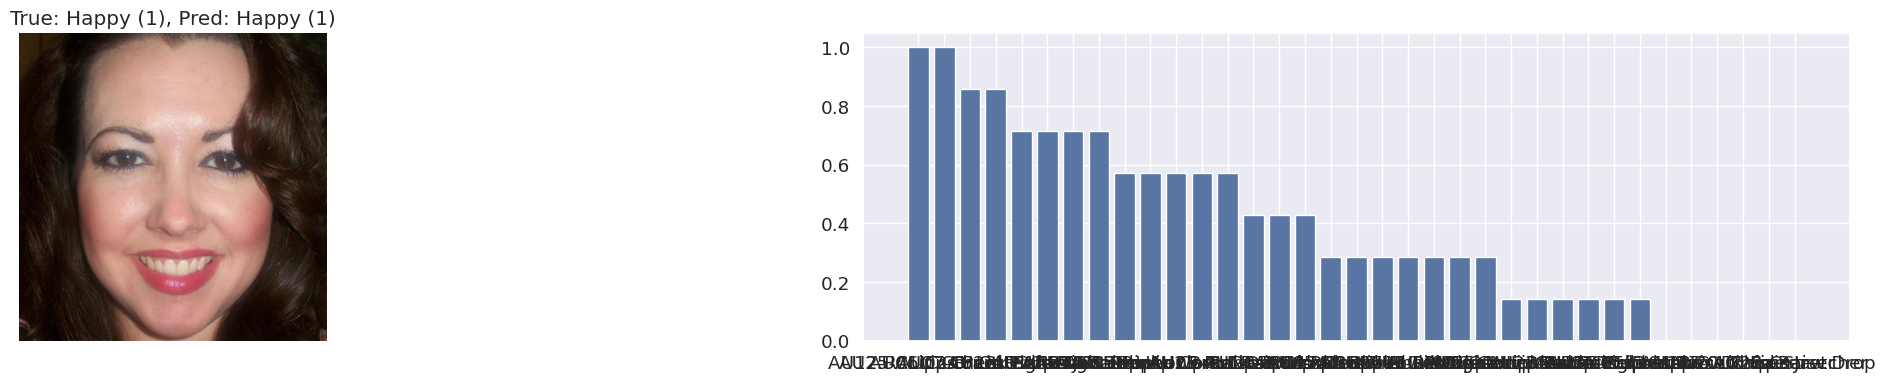

In [ ]:
for idx, desired in zip(img_idxs_corr, desired_classes_corr):
  plot_local_importance(idx, desired)

###################################
###################################
#### Instance 14 - True: Happy (1), Pred: Disgust (5)
#### Desired Outcome: Happy (1)



,AU01-R: Inner Brow Raiser,AU02-R: Outer Brow Raiser,AU04-R: Brow Lowerer,AU05-R: Upper Lid Raiser,AU06-R: Cheek Raiser,AU07-R: Lid Tightener,AU09-R: Nose Wrinkler,AU10-R: Upper Lip Raiser,AU12-R: Lip Corner Puller,AU14-R: Dimpler,AU15-R: Lip Corner Depressor,AU17-R: Chin Raiser,AU20-R: Lip Stretcher,AU23-R: Lip Tightener,AU25-R: Lips Part,AU26-R: Jaw Drop,AU45-R: Blink,AU01-C: Inner Brow Raiser,AU02-C: Outer Brow Raiser,AU04-C: Brow Lowerer,AU05-C: Upper Lid Raiser,AU06-C: Cheek Raiser,AU07-C: Lid Tightener,AU09-C: Nose Wrinkler,AU10-C: Upper Lip Raiser,AU12-C: Lip Corner Puller,AU14-C: Dimpler,AU15-C: Lip Corner Depressor,AU17-C: Chin Raiser,AU20-C: Lip Stretcher,AU23-C: Lip Tightener,AU25-C: Lips Part,AU26-C: Jaw Drop,AU28-C: Lip Suck,AU45-C: Blink
14,0.33,1.07,1.16,0.76,1.12,1.84,1.95,1.73,0.8,0.44,0.0,0.87,0.0,0.0,0.72,0.0,0.46,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


100%|██████████| 1/1 [00:00<00:00,  1.04it/s]


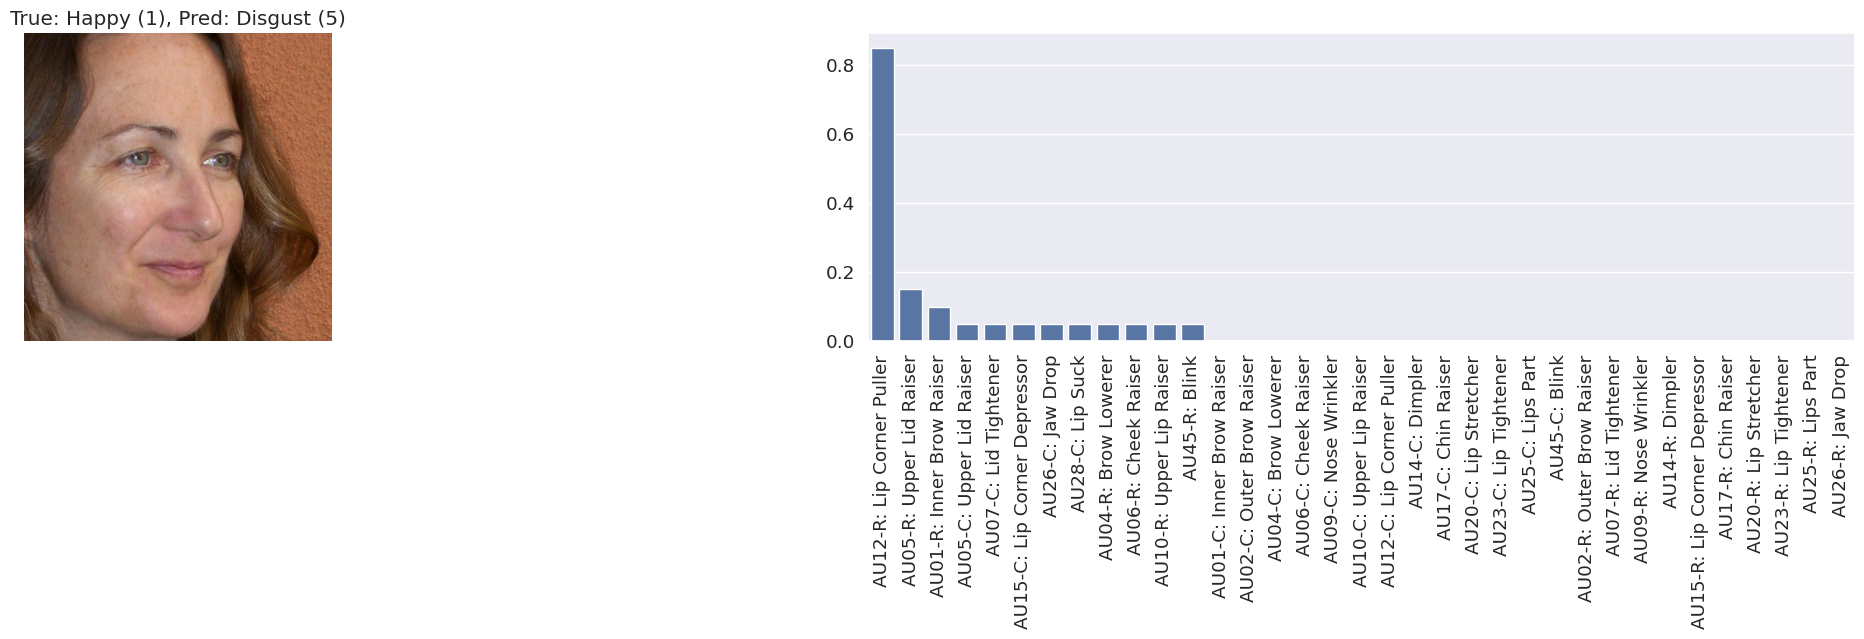

###################################
###################################
#### Instance 56 - True: Disgust (5), Pred: Anger (6)
#### Desired Outcome: Disgust (5)



,AU01-R: Inner Brow Raiser,AU02-R: Outer Brow Raiser,AU04-R: Brow Lowerer,AU05-R: Upper Lid Raiser,AU06-R: Cheek Raiser,AU07-R: Lid Tightener,AU09-R: Nose Wrinkler,AU10-R: Upper Lip Raiser,AU12-R: Lip Corner Puller,AU14-R: Dimpler,AU15-R: Lip Corner Depressor,AU17-R: Chin Raiser,AU20-R: Lip Stretcher,AU23-R: Lip Tightener,AU25-R: Lips Part,AU26-R: Jaw Drop,AU45-R: Blink,AU01-C: Inner Brow Raiser,AU02-C: Outer Brow Raiser,AU04-C: Brow Lowerer,AU05-C: Upper Lid Raiser,AU06-C: Cheek Raiser,AU07-C: Lid Tightener,AU09-C: Nose Wrinkler,AU10-C: Upper Lip Raiser,AU12-C: Lip Corner Puller,AU14-C: Dimpler,AU15-C: Lip Corner Depressor,AU17-C: Chin Raiser,AU20-C: Lip Stretcher,AU23-C: Lip Tightener,AU25-C: Lips Part,AU26-C: Jaw Drop,AU28-C: Lip Suck,AU45-C: Blink
56,0.42,0.0,3.6,0.0,0.93,1.76,0.63,0.26,0.0,0.0,0.62,0.55,0.09,0.0,0.33,0.18,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


100%|██████████| 1/1 [00:01<00:00,  1.94s/it]


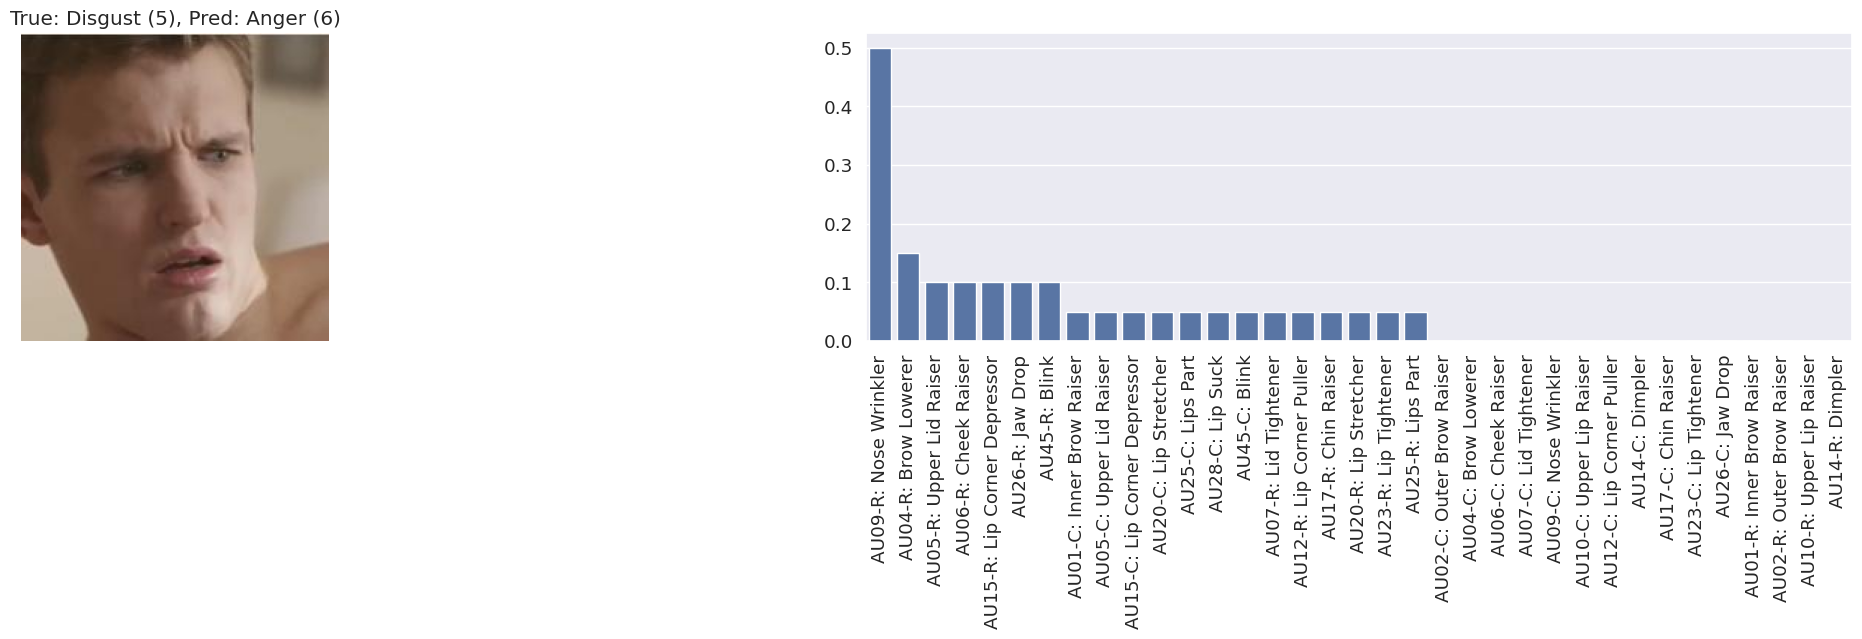

###################################
###################################
#### Instance 65 - True: Anger (6), Pred: Sad (2)
#### Desired Outcome: Disgust (5)



,AU01-R: Inner Brow Raiser,AU02-R: Outer Brow Raiser,AU04-R: Brow Lowerer,AU05-R: Upper Lid Raiser,AU06-R: Cheek Raiser,AU07-R: Lid Tightener,AU09-R: Nose Wrinkler,AU10-R: Upper Lip Raiser,AU12-R: Lip Corner Puller,AU14-R: Dimpler,AU15-R: Lip Corner Depressor,AU17-R: Chin Raiser,AU20-R: Lip Stretcher,AU23-R: Lip Tightener,AU25-R: Lips Part,AU26-R: Jaw Drop,AU45-R: Blink,AU01-C: Inner Brow Raiser,AU02-C: Outer Brow Raiser,AU04-C: Brow Lowerer,AU05-C: Upper Lid Raiser,AU06-C: Cheek Raiser,AU07-C: Lid Tightener,AU09-C: Nose Wrinkler,AU10-C: Upper Lip Raiser,AU12-C: Lip Corner Puller,AU14-C: Dimpler,AU15-C: Lip Corner Depressor,AU17-C: Chin Raiser,AU20-C: Lip Stretcher,AU23-C: Lip Tightener,AU25-C: Lips Part,AU26-C: Jaw Drop,AU28-C: Lip Suck,AU45-C: Blink
65,1.08,0.59,0.0,1.53,0.0,0.0,0.44,0.8,0.0,0.0,2.29,0.55,1.88,0.24,0.0,0.59,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


100%|██████████| 1/1 [00:02<00:00,  2.48s/it]


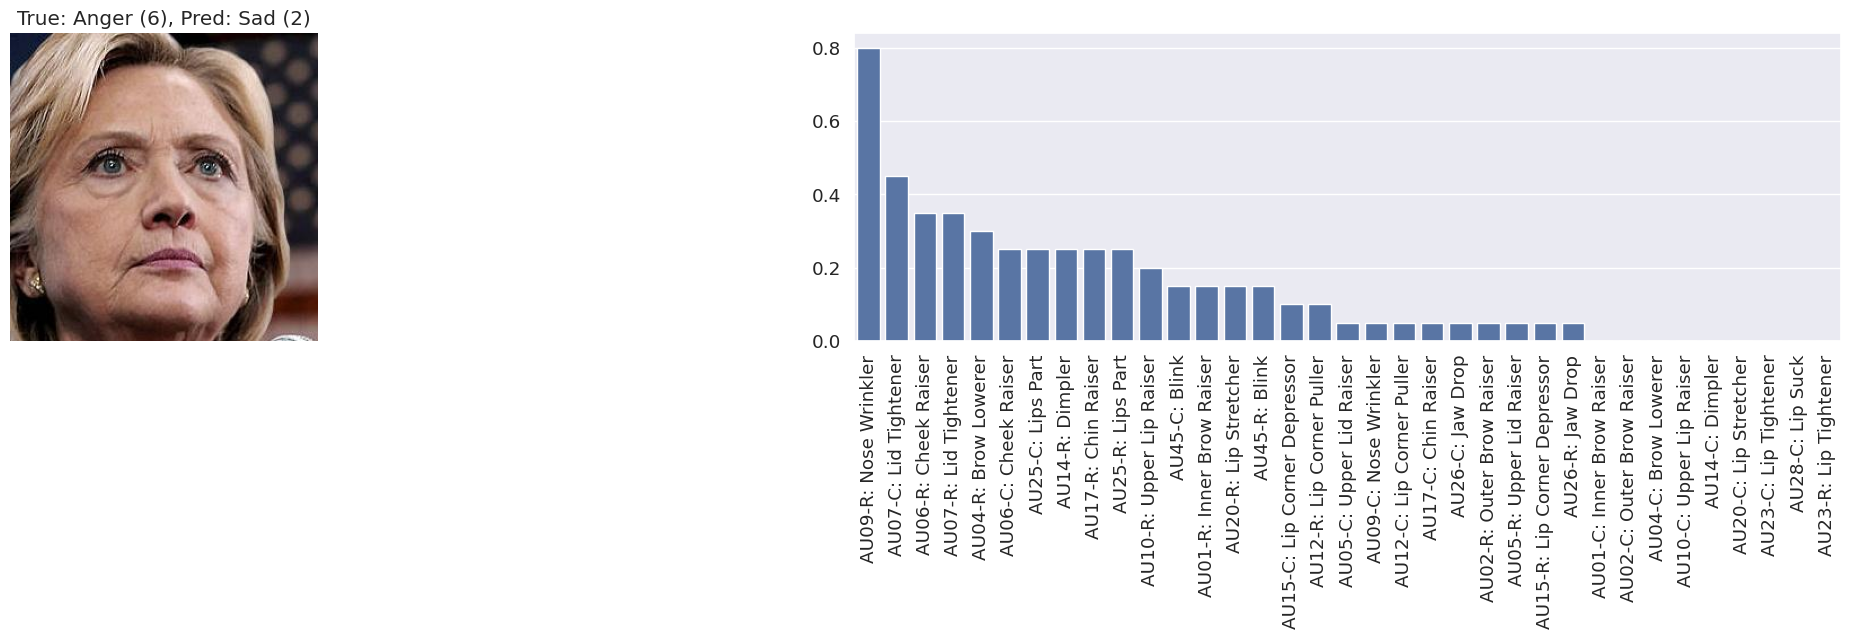

In [ ]:
for idx, desired in zip(img_idxs_incorr, desired_classes_incorr):
  plot_local_importance(idx, desired)

#### Global Feature Importance For Class: Neutral ####


100%|██████████| 10/10 [00:12<00:00,  1.21s/it]


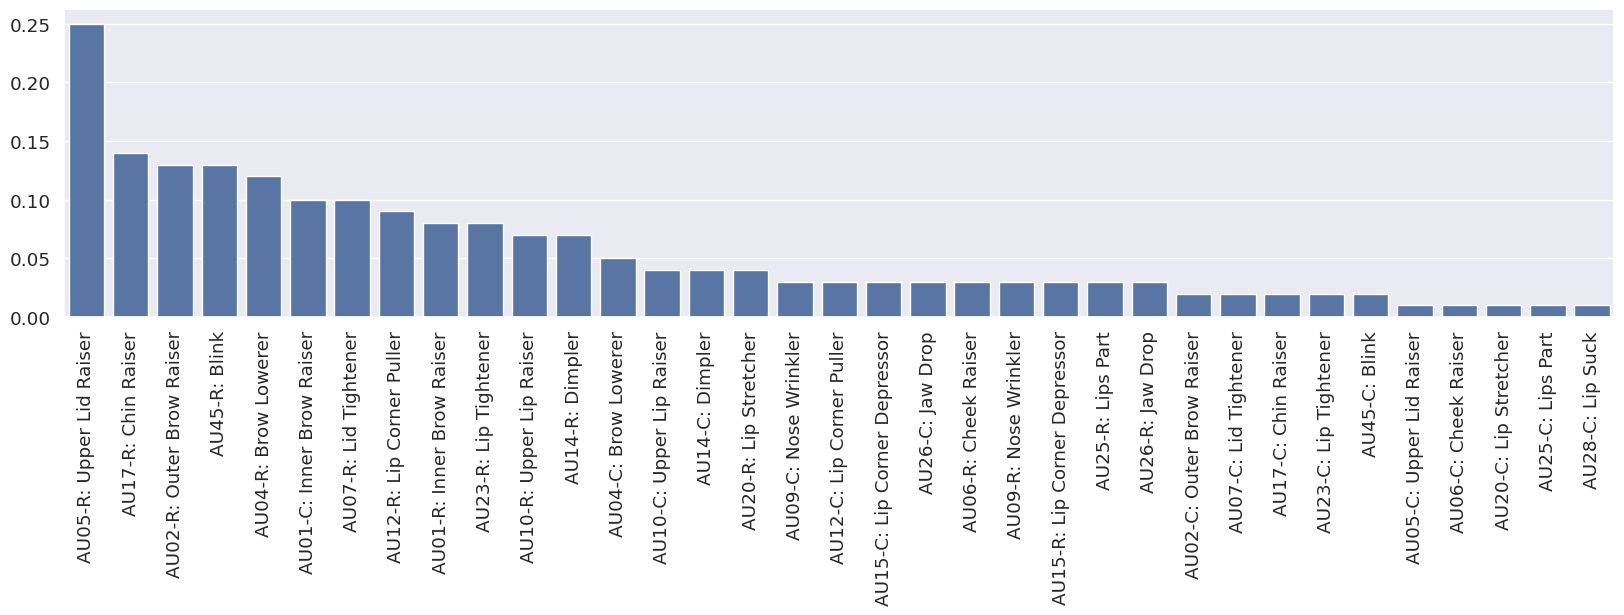


#### Global Feature Importance For Class: Happy ####


100%|██████████| 10/10 [00:17<00:00,  1.78s/it]


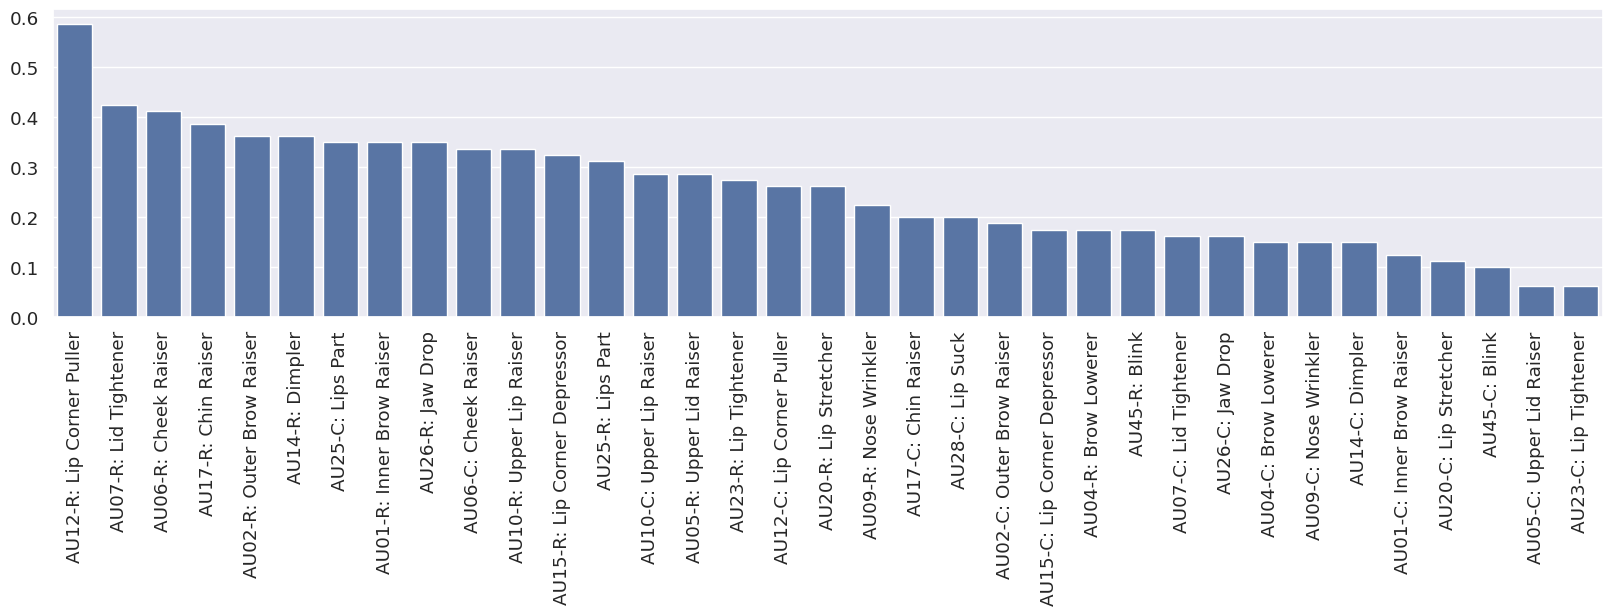


#### Global Feature Importance For Class: Sad ####


100%|██████████| 10/10 [00:07<00:00,  1.31it/s]


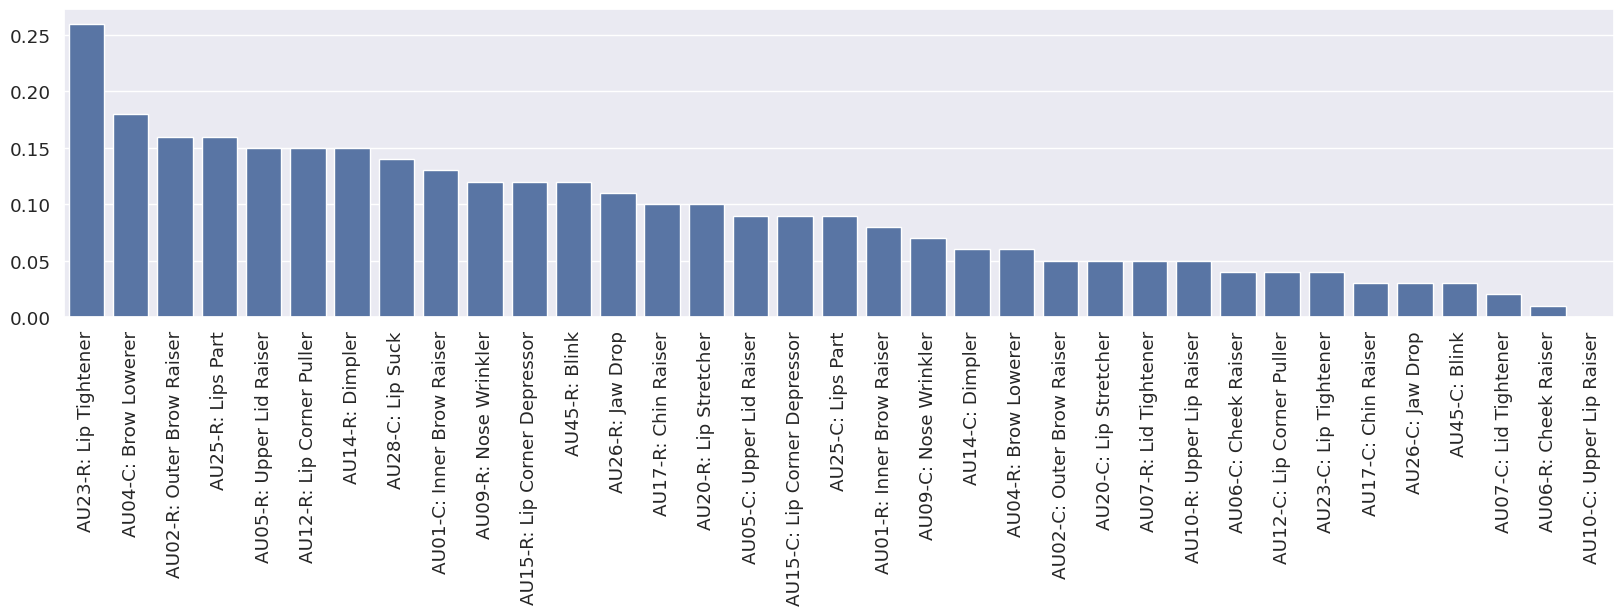


#### Global Feature Importance For Class: Surprise ####


100%|██████████| 10/10 [00:08<00:00,  1.13it/s]


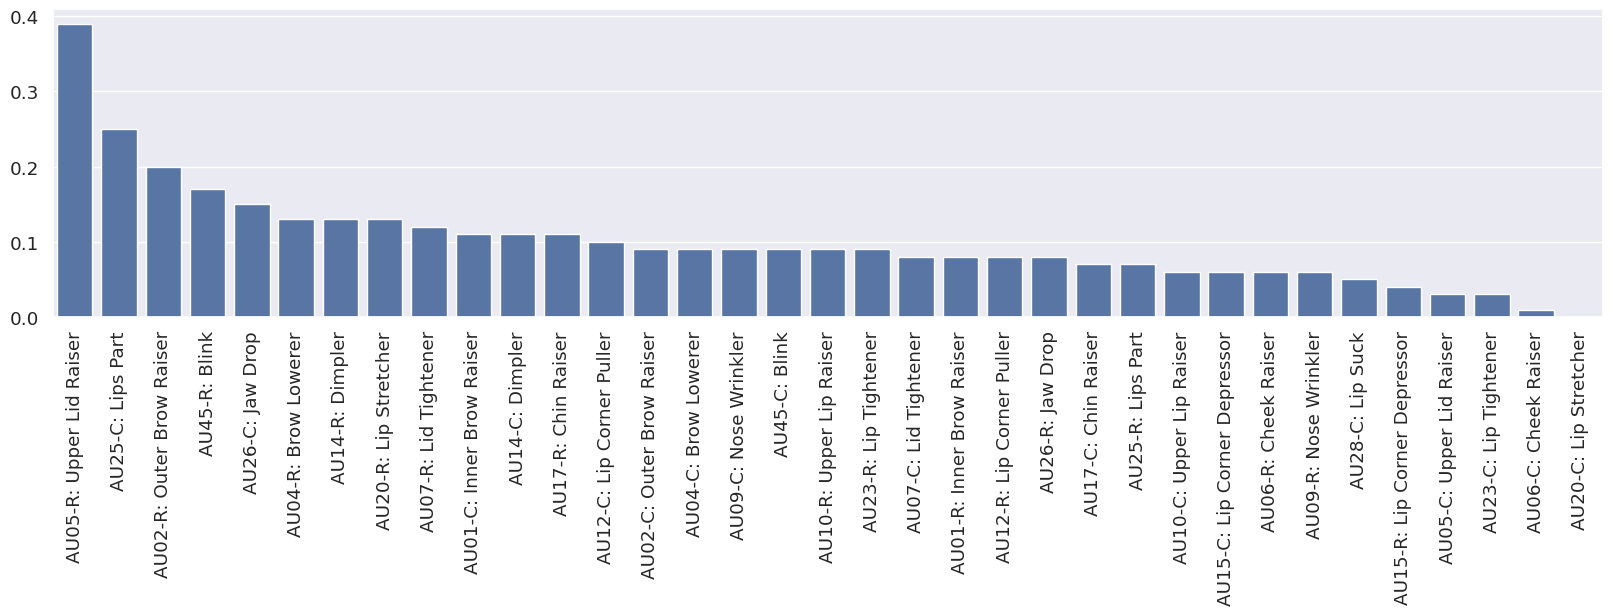


#### Global Feature Importance For Class: Fear ####


100%|██████████| 10/10 [00:10<00:00,  1.06s/it]


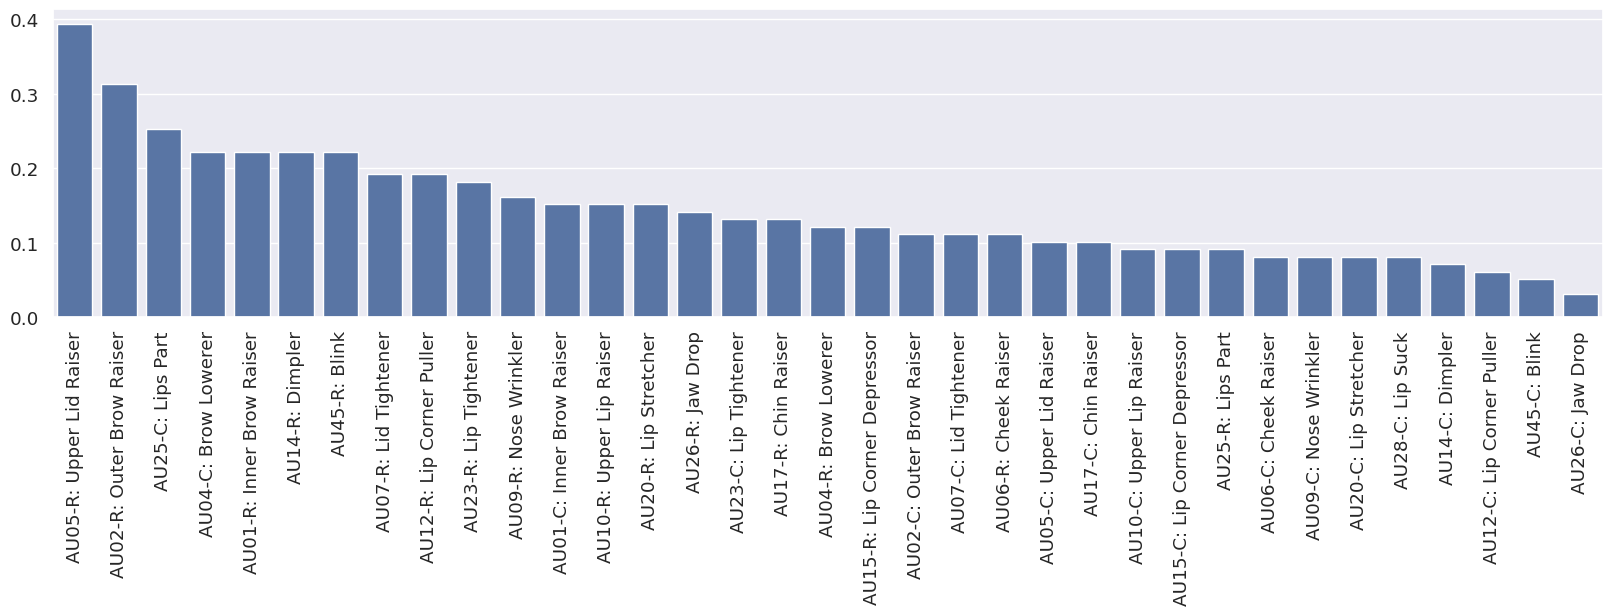


#### Global Feature Importance For Class: Disgust ####


100%|██████████| 10/10 [00:14<00:00,  1.43s/it]


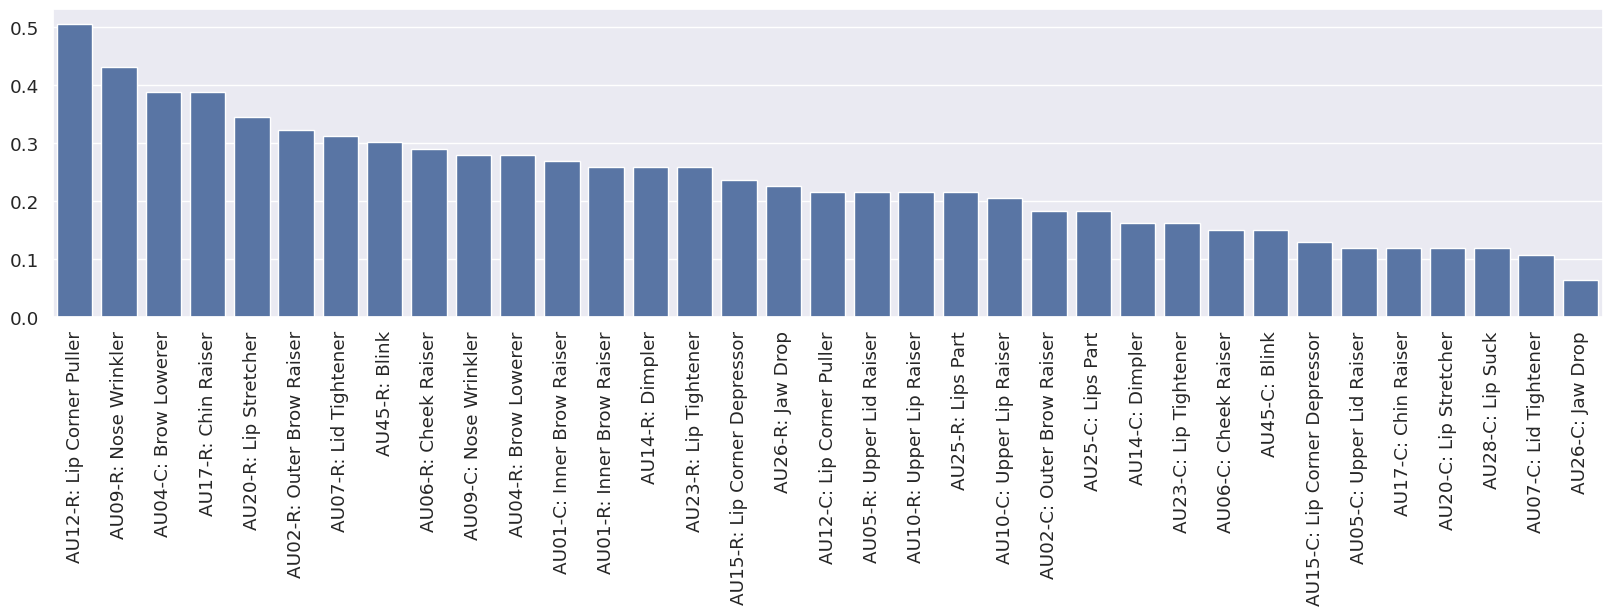


#### Global Feature Importance For Class: Anger ####


100%|██████████| 10/10 [00:09<00:00,  1.11it/s]


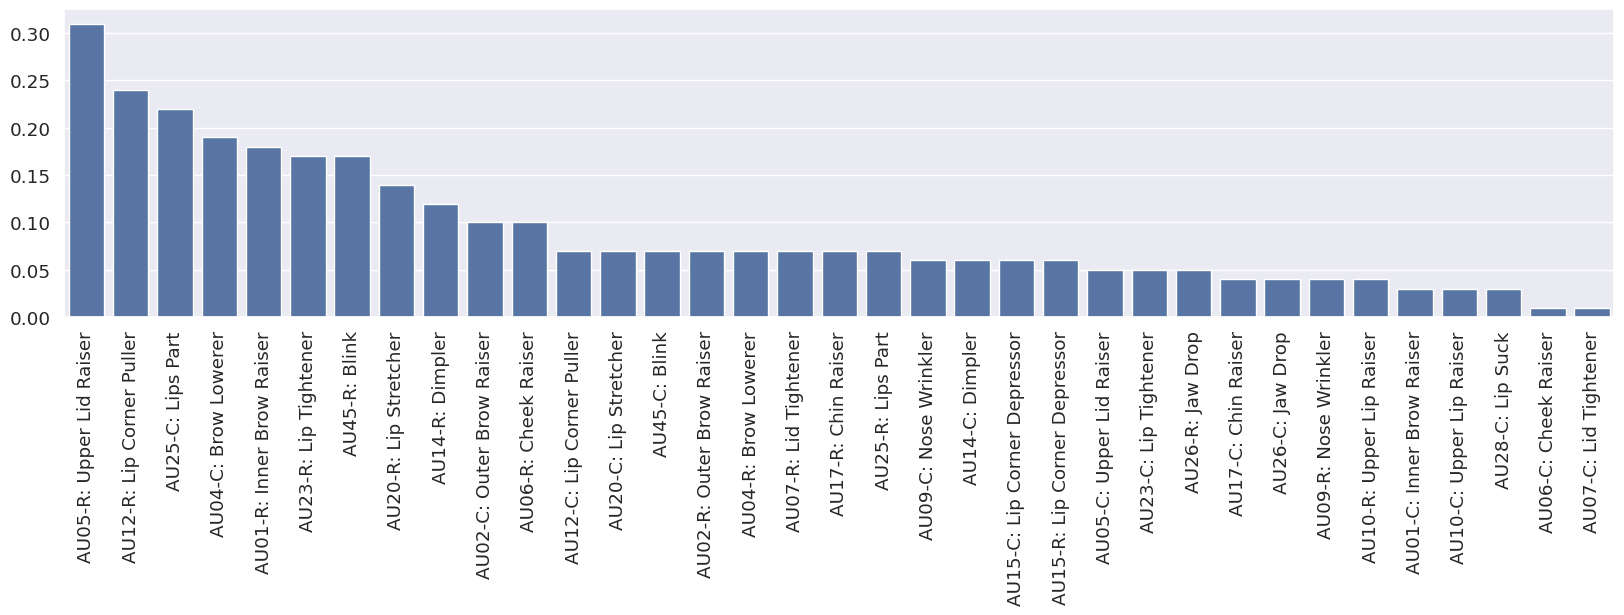


#### Global Feature Importance For Class: Contempt ####


100%|██████████| 10/10 [00:09<00:00,  1.07it/s]


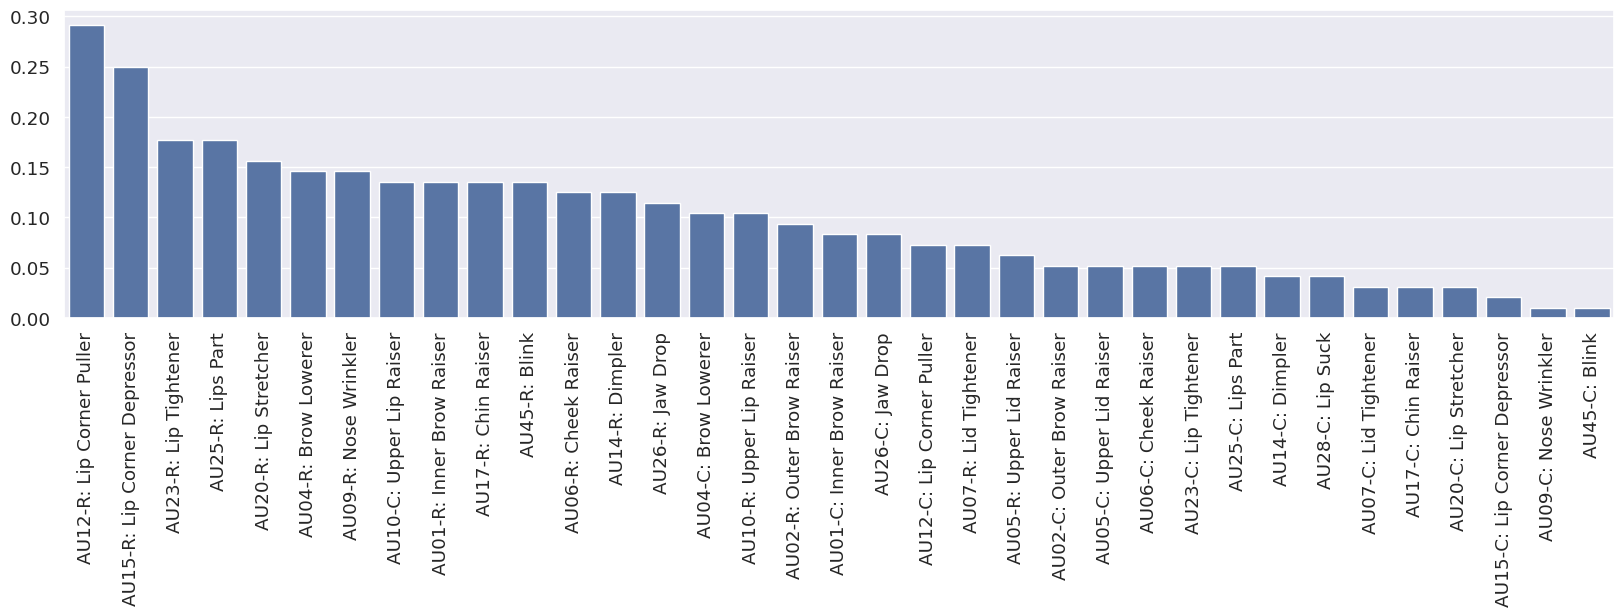

In [ ]:
for cls_idx in range(len(class_names)):
  desired_class = 0
  print(f'#### Global Feature Importance For Class: {class_names[cls_idx]} ####')
  imp = exp.global_feature_importance(df_xai[feature_names][cls_idx*10:cls_idx*10+10], desired_class=desired_class)
  plt.figure(figsize=(20, 4))
  plot_importance_dict(imp.summary_importance)
  plt.show()
  print()

#### Question 2

**Q 2.a**

How does the DiCE approach to local and global feature importance differ from SHAP?  

**Q 2.b**

Compare the results from each approach, are they similar? Can you interpret the feature importance values of each approach in the same way? Why or why not?

**Q 2.c**
Which method to you prefer and why?